# Stable Diffusion


Stable Diffusion is a latent text-to-image diffusion model capable of generating photo-realistic images given any text input.

Most diffusion systems consist of multiple independently-trained models, Stable Diffusion is composed of:

* A Text Encoder - encodes textual information into a multimodal embedding space
* A Unet - takes encoded text and a noisy array in latent space. Over many diffusion steps, it produces another array in the same latent space. 
* A Decoder - the decoder part of a variational autoencoder. It will take the array from latent space and output the pixel space rapresentation.
* A Safety Checker (Optional) - model that cheks for NSFW material in an image.

The other important component of a pipeline are the Scheduler and the Tokenizer.

While the UNet define the forward pass from noise to a less noisy sample, the Scheduler define the whole denoising process.
For example how to predict the noise and how many steps should it take.

The tokenizer is the preprocessor of the input prompt, it receives a stream of characters and breaks it up into individual tokens.
This individual token will all be sent to the Text encoder

The process can be seen in this image:

<img src="resources/stable_diffusion.png">



## PIP Packages Required

In [ ]:
# PIP INSTALLS
# These will eventually be already installed in the container, so there should be no pip install inside the notebook
!pip install accelerate

In [ ]:
#Otherwise weird noise on the image
!pip install diffusers==0.17.0rc0 

In [ ]:
#Transformers needs to be updated
!pip install --upgrade transformers

In [ ]:
#Install our qaic apis
!python3 -m pip install /opt/qti-aic/dev/lib/x86_64/qaic-0.0.1-py3-none-any.whl

In [ ]:
# Torch nigthly is needed, otherwise error while converting to onnx
!pip uninstall torch -y
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu

## Diffusers from Huggingface
[Diffusers from Huggingface](https://github.com/huggingface/diffusers) is currently the most used library for pretrained diffusion models.

In this notebook we will do two image generation:

1) **CPU Generation**
* Download a pipeline from Huggingface along with the stable diffusion model
* Execute the pipeline on the cpu to see the difference between the cpu execution and the aic100 execution

2) **CPU + AIC100 Generation**
* Load all the individual models and components of the stable diffusion pipeline but the UNet
* Offload the UNet component to the AIC100
* Run a simple diffusion loop with this new architecture and observe the speedup we obtain

In [12]:
#Imports
from diffusers import DiffusionPipeline,AutoencoderKL,PNDMScheduler
from transformers import CLIPTokenizer, CLIPTextModel
from diffusers.image_processor import VaeImageProcessor
from tqdm.auto import tqdm
import os
import torch
import numpy as np
import cv2

## Downloading the model from Huggingface
We are going to download the model using the diffusers library and save it locally

In [ ]:
# Downlaoding the model from the hf repo
pipe = DiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", safety_checker=None)
pipe.save_pretrained("./sd-v1-5")

In [ ]:
# We remove it from memory as it could lead to jupyter kernel fail
del pipe

# Executing the model using the CPU (**CPU Generation**)
By default the model is downloaded in pytorch format and runs on the cpu.

Here we can fully take advantage of the standard pipeline from huggingface diffusers library.
This allows us to generate an image with just 3 lines of code.


In [13]:
# Loading of the model from the local pipeline just downloaded
pipe = DiffusionPipeline.from_pretrained("./sd-v1-5", safety_checker=None)

result = pipe(prompt="a beetle car in the street o|f tokyo",num_inference_steps=20).images[0]
result.save("test_cpu.png")

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:09<00

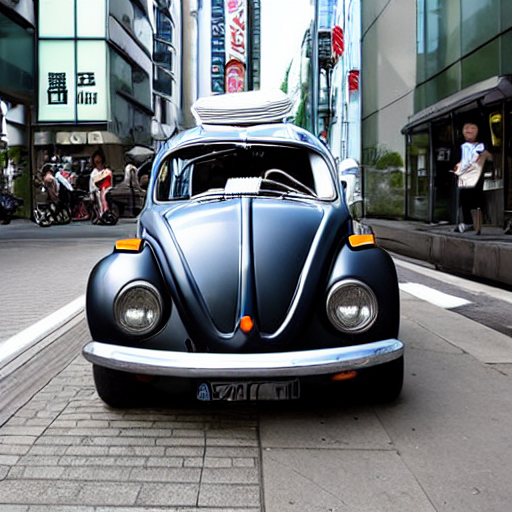

In [14]:
result

In [15]:
# We remove it from memory as it could lead to jupyter kernel fail
del pipe

# Running one component on the AIC100 (**CPU + AIC100 Generation**)
The most resource intensive part of stable diffusion is done in the UNet model, where the image is denoised.
We can offload this intensive task to the aic100.

To do that, we will create the most basic diffusion pipeline and substitute the Unet component with a custom one.

We are going to load all the component by hand:

* The Tokenizer and the Text encoder
* The UNet
* The Encoder
* The Scheduler
  
We are going to load all the component piece by piece from the original pipeline we already downloaded.

The only component left out is the UNet, the one we are running on the AIC100.

In [16]:
# Load the tokenizer and text encoder
tokenizer= CLIPTokenizer.from_pretrained("sd-v1-5", subfolder='tokenizer')
text_encoder= CLIPTextModel.from_pretrained("sd-v1-5", subfolder='text_encoder')

# Load the autoencoder model
vae = AutoencoderKL.from_pretrained("sd-v1-5", subfolder='vae')

# load the scheduler
scheduler= PNDMScheduler.from_pretrained("sd-v1-5", subfolder='scheduler')

# we also load the image processor, it is not mandatory, but it will help processing the created image
image_processor = VaeImageProcessor()

Now we need to assemble the pieces together, but first, we must create the last component, which is the U-Net.

To do so, we need to get from the Pytorch model to the "AIC Program Container" (QPC),
the binary format of the model that will be loaded on our card.

From Pytorch we will convert to ONNX and then compile to QPC.


So let's convert the Pytorch model to ONNX.
The following is a part of the script available [here](https://github.com/huggingface/diffusers/blob/main/scripts/convert_stable_diffusion_checkpoint_to_onnx.py) offered by Huggingface.

### Conversion of the UNet to ONNX
The conversion of a Pytorch model is heavely documented online. Here we are following a standard approach:
* We create a dummy input of the same dimension of a real input
* We list the oredered input of the forward method of the model we are interested in providing, in this case we are using the [UNet2DCondition](https://github.com/huggingface/diffusers/blob/main/src/diffusers/models/unet_2d_condition.py).
* We specify if we want any dynamic axis and their variables.

In [ ]:
import shutil
from pathlib import Path

from torch.onnx import export

import onnx
from diffusers import StableDiffusionPipeline
from diffusers import OnnxRuntimeModel
from packaging import version


is_torch_less_than_1_11 = version.parse(version.parse(torch.__version__).base_version) < version.parse("1.11")


def onnx_export(
    model,
    model_args: tuple,
    output_path: Path,
    ordered_input_names,
    output_names,
    dynamic_axes,
    opset,
    use_external_data_format=False,
):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    # PyTorch deprecated the `enable_onnx_checker` and `use_external_data_format` arguments in v1.11,
    # so we check the torch version for backwards compatibility
    if is_torch_less_than_1_11:
        export(
            model,
            model_args,
            f=output_path.as_posix(),
            input_names=ordered_input_names,
            output_names=output_names,
            dynamic_axes=dynamic_axes,
            do_constant_folding=True,
            use_external_data_format=use_external_data_format,
            enable_onnx_checker=True,
            opset_version=opset,
        )
    else:
        export(
            model,
            model_args,
            f=output_path.as_posix(),
            input_names=ordered_input_names,
            output_names=output_names,
            dynamic_axes=dynamic_axes,
            do_constant_folding=True,
            opset_version=opset,
        )


@torch.no_grad()
def convert_models(model_path: str, output_path: str, opset: int):
    pipeline = StableDiffusionPipeline.from_pretrained(model_path)
    output_path = Path(output_path)
    # UNET
    unet_path = output_path / "unet" / "model.onnx"
    onnx_export(
        pipeline.unet,
        model_args=(
            torch.randn(2, pipeline.unet.in_channels, 64, 64),
            torch.LongTensor([0, 1]),
            torch.randn(2, 77, 768),
            False,
        ),
        output_path=unet_path,
        ordered_input_names=["sample", "timestep", "encoder_hidden_states", "return_dict"],
        output_names=["out_sample"],  # has to be different from "sample" for correct tracing
        dynamic_axes={
            "sample": {0: "batch", 1: "channels", 2: "height", 3: "width"},
            "timestep": {0: "batch"},
            "encoder_hidden_states": {0: "batch", 1: "sequence"},
        },
        opset=opset,
        use_external_data_format=True,  # UNet is > 2GB, so the weights need to be split
    )
    unet_model_path = str(unet_path.absolute().as_posix())
    unet_dir = os.path.dirname(unet_model_path)
    unet = onnx.load(unet_model_path)
    # clean up existing tensor files
    shutil.rmtree(unet_dir)
    os.mkdir(unet_dir)
    # collate external tensor files into one
    onnx.save_model(
        unet,
        unet_model_path,
        save_as_external_data=True,
        all_tensors_to_one_file=True,
        location="weights.pb",
        convert_attribute=False,
    )
    del pipeline.unet

In [ ]:
# Convert the UNet with ONNX opset 14
convert_models("./sd-v1-5/","./sd-v1-5_onnx/",14)

## The UNet
Now that we have the ONNX, let's review what the UNet is and its inputs.

The UNet is the main component of the diffusion process, it is also called the noise predictor.

<img src="./resources/Stable_diffusion_paper.png">

Let's create a class that will do the job of the UNet using our Python APIs.

First we import qaic.

In [17]:
import qaic

In the __init__ method we load the QPC if available, otherwise we compile the model.

Let's analyze the various parameters passed to the qaic.Session() constructor.

| Parameter | Explanation |
| --- | --- |
| **onnx_define_symbol** | These comes from the dynamic axes of the onnx model that need to be "fixed" when compiling the model. These are normally the input dimensions that could be changed dynamically at runtime when using the ONNXRuntime. Here, since we compile them to a QPC, we need them to be fixed |
| **dev_id** | The device id we are going to use for our calculation|
| **mos** | Effort level to reduce the on-chip memory|
| **aic_num_cores** | 	Number of aic cores to be used for inference |
| **convert_to_fp16** | Run all floating-point in fp16 |


It is important to note that the **onnx_define_symbol** changes for each model.

In [18]:
class AIC100UNet():
    def __init__(self,model_path):
        qpc_model_path = model_path + "/programqpc.bin"
        yaml_options_path = model_path + "/options.yaml"
        if os.path.exists(qpc_model_path):
            self.session = qaic.Session(qpc_model_path, options_path=yaml_options_path)
            # file or directory exists
        else:
            self.session = qaic.Session(model_path+"/model.onnx", 
                                        onnx_define_symbol={"batch":2,
                                                            "sequence":77,
                                                            "channels":4,
                                                            "height":64,
                                                            "width":64},
                                        dev_id=1,
                                        mos=2,
                                        aic_num_cores=14,
                                        convert_to_fp16=True,
                                        output_dir=model_path
                                       )

    def run(self, input_data):
        # input_data : contains list of inputs in a sequence expected by model
        model_output = self.session.run(input_data)
        return model_output

## Our basic pipeline
When using Diffusers, the user can create a custom pipeline inheriting from the DiffusionPipeline class as described [here](https://huggingface.co/docs/diffusers/using-diffusers/contribute_pipeline).

In our simple example we just load the component of a diffusion pipeline by hand.
This is not advisable, but this approach is the one that best adapts to a notebook setting.

**We will need:**
- A way to convert the prompt to token and the token to embeddings, we will use the tokenizer and the text encoder already present in the standard stable diffusion pipeline we downloaded earlier.

In [19]:
def get_text_embeds(prompt):
  # Tokenize text and get embeddings
  text_input = tokenizer(
      prompt,
      padding='max_length', 
      max_length=tokenizer.model_max_length,
      truncation=True, 
      return_tensors='pt')

  with torch.no_grad():
    text_embeddings = text_encoder(text_input.input_ids)[0]

  # Do the same for unconditional embeddings
  uncond_input = tokenizer(
      [''] * len(prompt),
      padding='max_length',
      max_length=tokenizer.model_max_length, 
      return_tensors='pt')

  with torch.no_grad():
    uncond_embeddings = text_encoder(uncond_input.input_ids)[0]

  # concatenate the embeddings
  text_embeddings = torch.cat([uncond_embeddings, text_embeddings])
  return text_embeddings

- A way to produce the latents and predict the noise. This is where our custom UNet will operate.

  **Here called the myUnet**

In [20]:
def produce_latents(text_embeddings, height=512, width=512,
                    num_inference_steps=50, guidance_scale=7.5):

    myUnet = AIC100UNet("./sd-v1-5_onnx/unet")
    latents = torch.randn((text_embeddings.shape[0] // 2, 4, height // 8, width // 8))
    scheduler.set_timesteps(num_inference_steps)
    latents= latents*scheduler.init_noise_sigma       
    timestep_dtype = np.int64
    
    for i, t in tqdm(enumerate(scheduler.timesteps)):
    
        # expand the latents if we are doing classifier-free guidance to avoid doing two forward passes.
        latent_model_input = torch.cat([latents] * 2)
        latent_model_input = scheduler.scale_model_input(latent_model_input, t)
        latent_model_input = latent_model_input.cpu().numpy()
    
        timestep = np.array([t]*2*latents.shape[0], dtype=timestep_dtype)
        
        # predict the noise residual
        # Create the input dictionary of np array
        inputs={}
        inputs['sample']=latent_model_input
        inputs['timestep']=timestep
        inputs['encoder_hidden_states']=text_embeddings.cpu().numpy()
        # run the unet
        noise_pred = myUnet.run(inputs)
        # Get the result and shape it
        noise_pred = noise_pred['out_sample']
        noise_pred = noise_pred.reshape(2, 4, 64, 64)
        
        # perform guidance
        noise_pred_uncond, noise_pred_text = np.split(noise_pred, 2)
        noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

        # compute the previous noisy sample x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents).prev_sample
  
    return latents

- A way to decode the image from the latent representation

In [21]:
def decode_img_latents(latents):
  latents = 1 / 0.18215 * latents
  with torch.no_grad():
      image = vae.decode(latents, return_dict=False)[0]
  image = image_processor.postprocess(image)
  return image

## Putting it all togheter
Now that we have all the main functions we can create our simple handmade pipeline.

In [22]:
def prompt_to_img(prompts, height=512, width=512, num_inference_steps=50,
                  guidance_scale=7.5):
  if isinstance(prompts, str):
    prompts = [prompts]
  # From the Prompts to text embeds
  text_embeds = get_text_embeds(prompts)
  
  # From the initial random latents to the latents representing the image
  latents = produce_latents(
      text_embeds, height=height, width=width,
      num_inference_steps=num_inference_steps, guidance_scale=guidance_scale)
  
  # From the latents representing the images to an actual image
  imgs = decode_img_latents(latents)

  return imgs

In [23]:
img = prompt_to_img('a beetle car in the street of tokyo',512,512,20)[0]
img.save("test_aic.png")

0it [00:00, ?it/s]qaic: WARNING: Acitvating network, this will add up to time of first inference
21it [00:04,  4.41it/s]


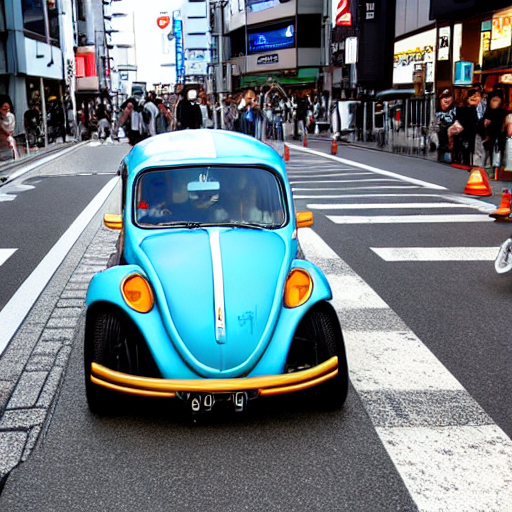

In [24]:
#Display the Image on the notebook
img